Student Name: Gokulnaath M
Roll No: 24BAD026
Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)
Training Set : (45000, 32, 32, 3)
Validation Set : (5000, 32, 32, 3)
Testing Set : (10000, 32, 32, 3)


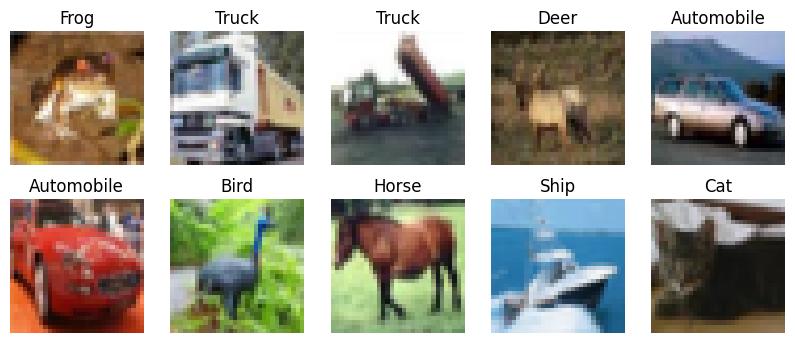

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

print("Student Name: Gokulnaath M")
print("Roll No: 24BAD026")

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels into one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Create Validation Set
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training Set :", x_train.shape)
print("Validation Set :", x_val.shape)
print("Testing Set :", x_test.shape)

# Display sample images
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

plt.show()

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))

# Output Layer
model.add(Dense(10,activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    x_train,
    y_train,
    epochs=7,
    batch_size=64,
    validation_data=(x_val,y_val)
)

Epoch 1/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.5915 - loss: 1.1642 - val_accuracy: 0.6122 - val_loss: 1.0974
Epoch 2/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 84ms/step - accuracy: 0.6423 - loss: 1.0325 - val_accuracy: 0.6490 - val_loss: 1.0125
Epoch 3/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.6763 - loss: 0.9386 - val_accuracy: 0.6462 - val_loss: 1.0162
Epoch 4/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.7010 - loss: 0.8665 - val_accuracy: 0.6704 - val_loss: 0.9886
Epoch 5/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.7209 - loss: 0.8040 - val_accuracy: 0.6756 - val_loss: 0.9379
Epoch 6/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.7448 - loss: 0.7367 - val_accuracy: 0.6982 - val_loss: 0.8933
Epoch 7/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7639 - loss: 0.6803 - val_accuracy: 0.6916 - val_loss: 0.9258


In [6]:
test_loss, test_accuracy = model.evaluate(x_test,y_test)

print("Testing Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6948 - loss: 0.9348
Testing Accuracy : 0.6948000192642212


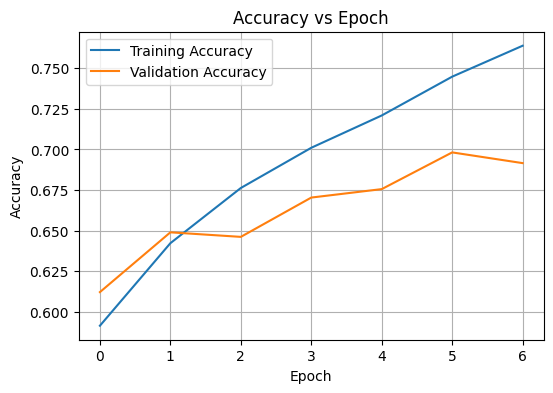

In [7]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

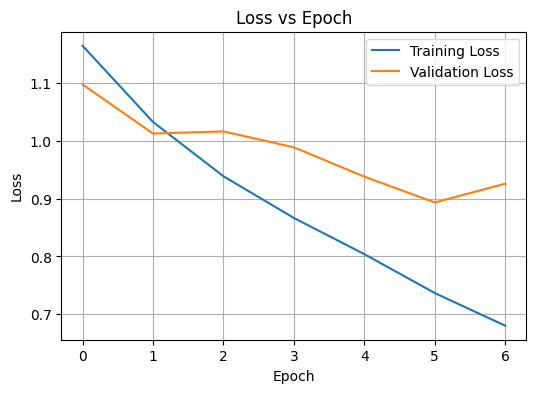

In [8]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


<Figure size 800x800 with 0 Axes>

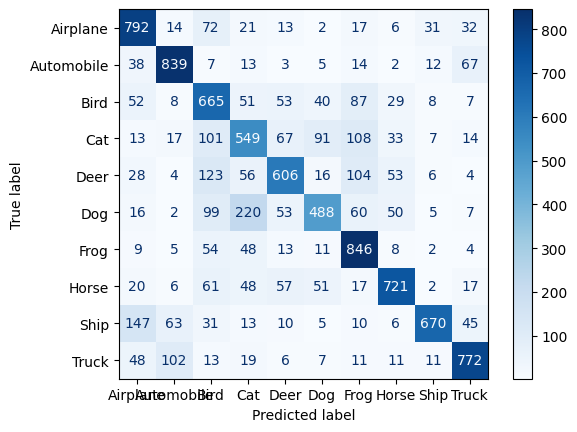

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model.predict(x_test)

y_pred = np.argmax(predictions,axis=1)
y_true = np.argmax(y_test,axis=1)

cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.show()

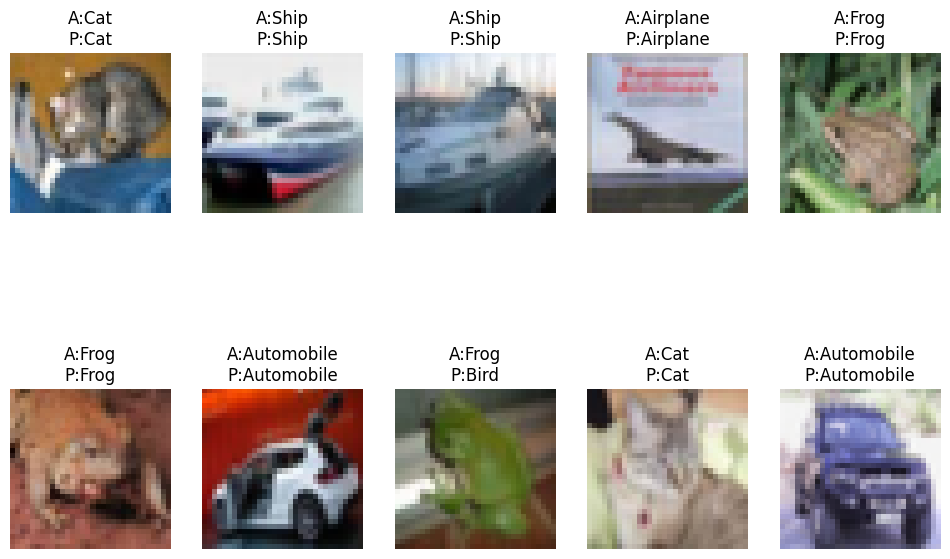

In [10]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    plt.title(f"A:{actual}\nP:{predicted}")

    plt.axis("off")

plt.show()

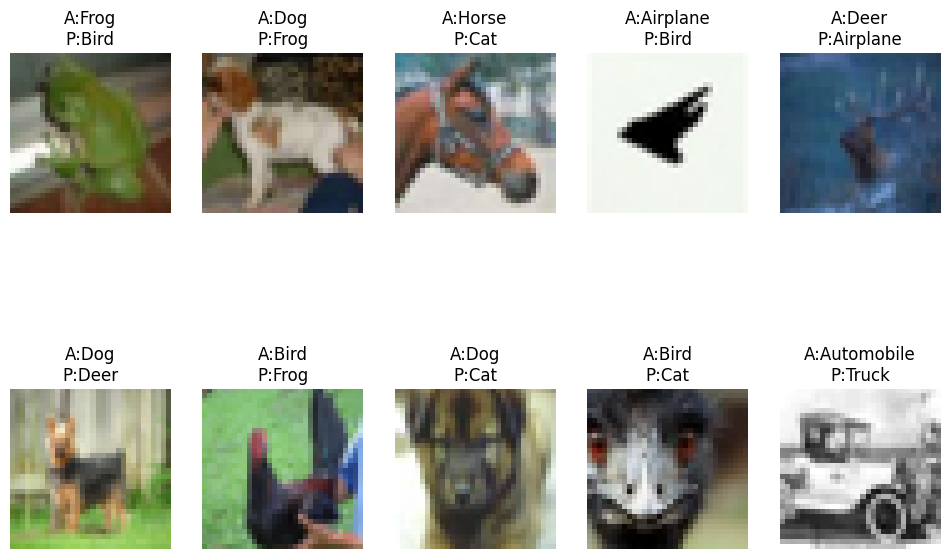

In [11]:
misclassified = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12,8))

for i,index in enumerate(misclassified[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[index])

    actual = class_names[y_true[index]]
    predicted = class_names[y_pred[index]]

    plt.title(f"A:{actual}\nP:{predicted}")

    plt.axis("off")

plt.show()